# Part 3: Analysis

**Main question:** Is India really replacing China as the phone factory for America, and what changed after the
2025 US tariffs?

Questions I answer in this notebook:
1. How big is the US smartphone import market and who supplies it?
2. How did each country's share change month by month?
3. Why does India's share drop every September?
4. What kind of phones does each country make? (price per phone)
5. Where do India's smartphones go?
6. Do India's and America's numbers match?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

# same colour for each country in every chart
colors = {"India": "#FF9933", "China": "#D62728", "Vietnam": "#2CA02C", "Others": "#B0B0B0"}

us = pd.read_csv("../data/cleaned/us_smartphone_imports.csv", parse_dates=["date"])
india = pd.read_csv("../data/cleaned/india_smartphone_exports.csv", parse_dates=["date"])

print("US imports:", us.shape, "| India exports:", india.shape)
print("US data:", us["date"].min().strftime("%b %Y"), "to", us["date"].max().strftime("%b %Y"))

US imports: (2001, 13) | India exports: (2085, 13)
US data: Jan 2022 to Jul 2026


Most of the market is just three countries, so I group everyone else as "Others":

In [2]:
share_all_years = us.groupby("country")["value_usd"].sum().sort_values(ascending=False)
(share_all_years / share_all_years.sum() * 100).head(6).round(1)

country
China          66.0
India          20.1
Vietnam        12.3
South Korea     0.8
Hong Kong       0.3
Indonesia       0.2
Name: value_usd, dtype: float64

In [3]:
us["supplier"] = us["country"].where(us["country"].isin(["India", "China", "Vietnam"]), "Others")

## Q1. How big is the market and who supplies it?

2026 only has data up to July. To compare years fairly I use **January to July** of every year.

In [4]:
jan_jul = us[us["month"] <= 7]
yearly = jan_jul.pivot_table(index="year", columns="supplier", values="value_usd", aggfunc="sum") / 1e9
yearly = yearly[["India", "China", "Vietnam", "Others"]]
yearly["Total"] = yearly.sum(axis=1)
yearly.round(2)

supplier,India,China,Vietnam,Others,Total
year,,,,,
2022,0.47,27.11,8.24,0.84,36.66
2023,2.77,21.16,5.41,0.84,30.18
2024,4.45,18.66,1.31,0.31,24.74
2025,13.25,12.00,3.55,0.41,29.21
2026,16.45,8.52,3.02,0.38,28.37


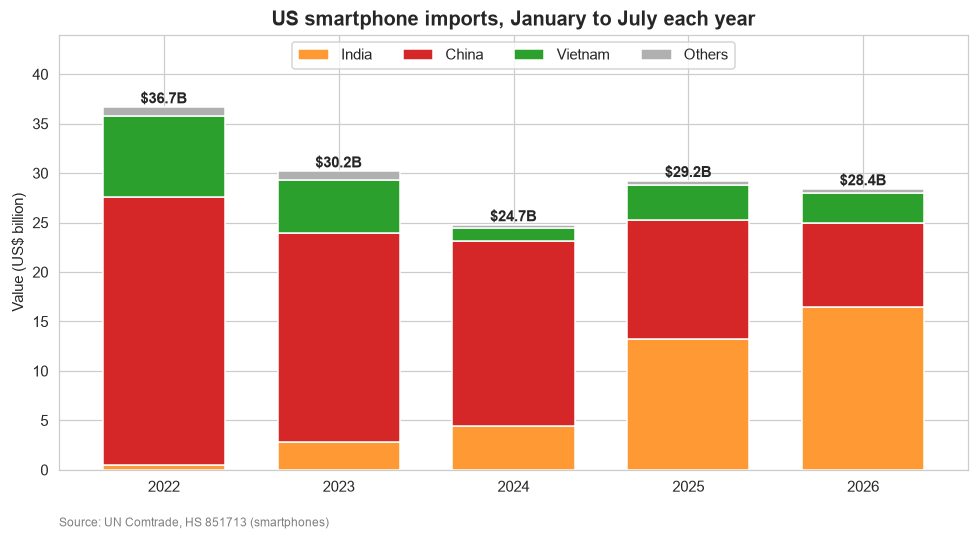

In [5]:
ax = yearly[["India", "China", "Vietnam", "Others"]].plot(
    kind="bar", stacked=True, figsize=(9, 5), color=[colors[c] for c in ["India", "China", "Vietnam", "Others"]], width=0.7)

for i, total in enumerate(yearly["Total"]):
    ax.text(i, total + 0.4, f"${total:.1f}B", ha="center", fontweight="bold")

ax.set_title("US smartphone imports, January to July each year", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Value (US$ billion)")
ax.set_xticklabels(yearly.index, rotation=0)
ax.set_ylim(0, 44)
ax.legend(title="", loc="upper center", ncol=4)
ax.text(0, -0.13, "Source: UN Comtrade, HS 851713 (smartphones)", transform=ax.transAxes, fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../images/01_us_imports_by_year.png", bbox_inches="tight")
plt.show()

In [6]:
growth = yearly.loc[2026, "India"] / yearly.loc[2022, "India"]
print(f"India (Jan-Jul): ${yearly.loc[2022, 'India']:.2f}B in 2022 -> ${yearly.loc[2026, 'India']:.2f}B in 2026 ({growth:.0f}x)")
print(f"China (Jan-Jul): ${yearly.loc[2022, 'China']:.2f}B in 2022 -> ${yearly.loc[2026, 'China']:.2f}B in 2026")

India (Jan-Jul): $0.47B in 2022 -> $16.45B in 2026 (35x)
China (Jan-Jul): $27.11B in 2022 -> $8.52B in 2026


**What I found:**
- The total market actually got **smaller**, from about $36.7B to $28.4B for the same seven months.
- Inside a shrinking market, **India grew about 35 times**, while China fell to less than a third of its 2022 level.
- So India is not just growing with the market. It is **taking China's place**.

## Q2. Month-by-month share

Yearly totals hide *when* things changed, so here is the share of each country for every month.

In [7]:
monthly = us.pivot_table(index="date", columns="supplier", values="value_usd", aggfunc="sum")
monthly_share = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_share = monthly_share[["India", "China", "Vietnam", "Others"]]
monthly_share.tail(6).round(1)

supplier,India,China,Vietnam,Others
date,,,,
2026-02-01,66.1,22.7,9.5,1.7
2026-03-01,56.3,32.6,9.6,1.5
2026-04-01,67.4,22.4,8.8,1.4
2026-05-01,54.1,33.0,11.4,1.6
2026-06-01,51.8,34.8,11.8,1.6
2026-07-01,57.0,27.8,14.1,1.1


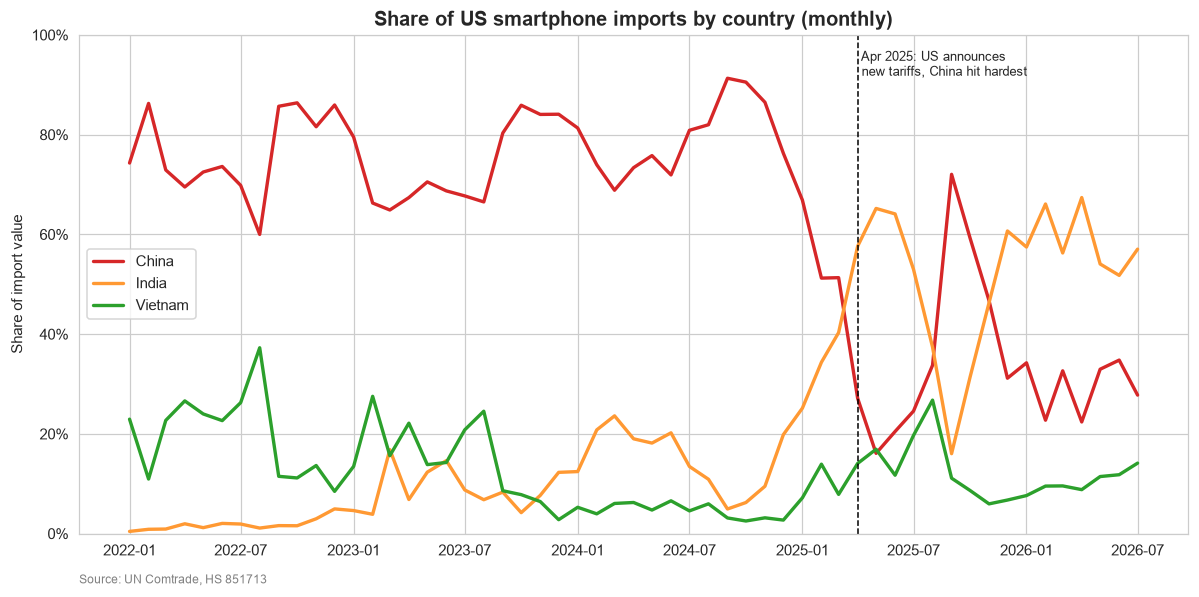

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for country in ["China", "India", "Vietnam"]:
    ax.plot(monthly_share.index, monthly_share[country], label=country, color=colors[country], linewidth=2.2)

# tariff announcement
tariff_date = pd.Timestamp("2025-04-01")
ax.axvline(tariff_date, color="black", linestyle="--", linewidth=1)
ax.text(tariff_date, 97, " Apr 2025: US announces\n new tariffs, China hit hardest", fontsize=8.5, va="top")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
ax.set_title("Share of US smartphone imports by country (monthly)", fontsize=13, fontweight="bold")
ax.set_ylabel("Share of import value")
ax.legend(loc="center left")
ax.text(0, -0.1, "Source: UN Comtrade, HS 851713", transform=ax.transAxes, fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../images/02_monthly_share.png", bbox_inches="tight")
plt.show()

When did India first send more phones (by value) to the US than China?

In [9]:
india_ahead = monthly_share[monthly_share["India"] > monthly_share["China"]]
first_month = india_ahead.index.min()
print("First month India > China:", first_month.strftime("%B %Y"))
print(monthly_share.loc[first_month, ["India", "China"]].round(1).to_dict())

since = monthly_share.loc[first_month:]
print(f"Since then India was ahead in {(since['India'] > since['China']).sum()} of {len(since)} months")
print("Months where China was still ahead:", [d.strftime("%b %Y") for d in since.index[since["China"] > since["India"]]])

First month India > China: April 2025
{'India': 57.6, 'China': 27.1}
Since then India was ahead in 13 of 16 months
Months where China was still ahead: ['Sep 2025', 'Oct 2025', 'Nov 2025']


In [10]:
# full calendar year 2025
y2025 = us[us["year"] == 2025].groupby("supplier")["value_usd"].sum() / 1e9
print("Full year 2025 (US$ billion):")
print(y2025.sort_values(ascending=False).round(2))

Full year 2025 (US$ billion):
supplier
China      23.68
India      22.15
Vietnam     5.89
Others      0.68
Name: value_usd, dtype: float64


**What I found:**
- India was under 5% of US smartphone imports for most of 2022.
- It crossed China for the first time in **April 2025**, the same month the US announced its new tariffs, with China
  facing much higher tariffs than India. India's share jumped from about 40% in March to 58% in April.
- Since April 2025 India has been ahead in 13 of 16 months, and in **every** month of 2026 so far.
- For full-year 2025 China was still just ahead ($23.7B vs $22.2B), only because China came back on top in
  **September to November 2025**. That's the next question.

*Note: this shows the timing matches, not that the tariffs alone caused it. India's share was already rising
since 2023.*

## Q3. Why does India's share drop every September?

In the chart above India's line dips every year around September and October. Let me check it year by year.

In [11]:
india_share = monthly_share["India"].to_frame("india_share")
india_share["year"] = india_share.index.year
india_share["month"] = india_share.index.month

pattern = india_share.pivot_table(index="month", columns="year", values="india_share")
pattern.loc[[7, 8, 9, 10, 11, 12]].round(1)

year,2022,2023,2024,2025,2026
month,,,,,
7,1.9,8.7,13.5,53.0,57.0
8,1.1,6.8,10.9,37.4,NaN
9,1.6,8.3,4.9,16.0,NaN
10,1.6,4.2,6.2,31.3,NaN
11,3.0,7.7,9.5,46.3,NaN
12,4.9,12.3,19.8,60.7,NaN


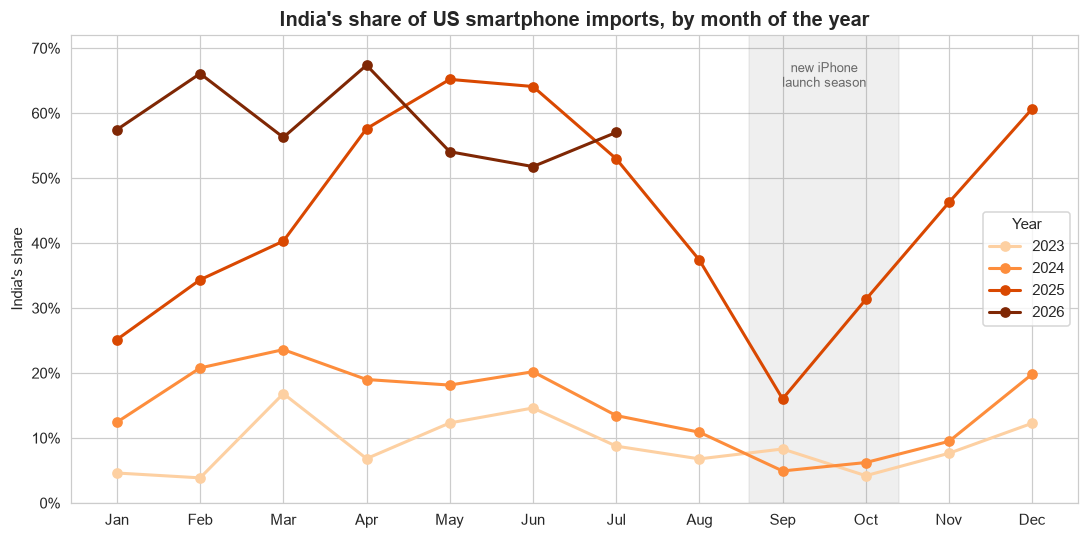

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
year_colors = {2023: "#FDD0A2", 2024: "#FD8D3C", 2025: "#D94801", 2026: "#7F2704"}
for year in [2023, 2024, 2025, 2026]:
    ax.plot(pattern.index, pattern[year], marker="o", label=str(year), color=year_colors[year], linewidth=2)

ax.axvspan(8.6, 10.4, color="gray", alpha=0.12)
ax.text(9.5, 68, "new iPhone\nlaunch season", ha="center", va="top", fontsize=8.5, color="dimgray")
ax.set_ylim(0, 72)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("India's share of US smartphone imports, by month of the year", fontsize=13, fontweight="bold")
ax.set_ylabel("India's share")
ax.legend(title="Year")
plt.tight_layout()
plt.savefig("../images/03_september_dip.png", bbox_inches="tight")
plt.show()

**What I found:** every year India's share falls in September/October and climbs back by December. The lowest
points were Oct 2023 (4%), Sep 2024 (5%) and Sep 2025 (16%). Apple launches new iPhones every September.

**My guess:** the first big batches of the new models still come mostly from China, and India's factories
catch up a few months later. The data can't prove this (it doesn't say which brand or model), but the pattern
repeats three years in a row, and the dip is getting smaller each year, so India seems to be making more of
the launch-season phones over time.

## Q4. Price per phone: what kind of phones does each country make?

I use the average price per phone (value / quantity). 2022 is left out because its quantities were estimated
(see the cleaning notebook), and tiny shipments are already removed.

In [13]:
priced = us.dropna(subset=["price_per_phone"])
priced = priced[priced["country"].isin(["India", "China", "Vietnam"])]

avg_price = priced.groupby(["year", "country"]).apply(
    lambda g: g["value_usd"].sum() / g["quantity"].sum(), include_groups=False).unstack()
avg_price = avg_price[["India", "China", "Vietnam"]]
avg_price.round(0)

country,India,China,Vietnam
year,,,
2023,456.0,377.0,433.0
2024,466.0,355.0,303.0
2025,432.0,389.0,238.0
2026,533.0,357.0,242.0


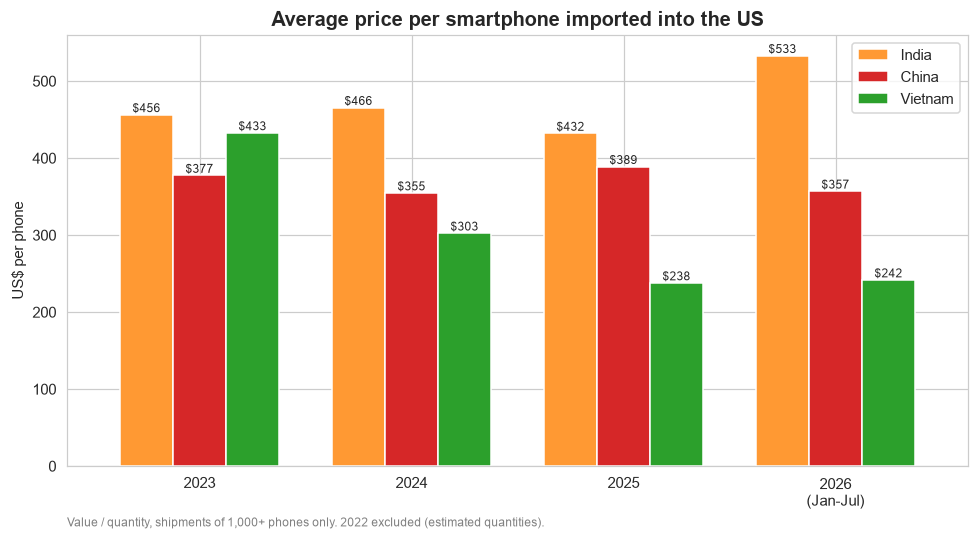

In [14]:
ax = avg_price.plot(kind="bar", figsize=(9, 5), color=[colors[c] for c in avg_price.columns], width=0.75)
for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", fontsize=8)
ax.set_title("Average price per smartphone imported into the US", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("US$ per phone")
ax.set_xticklabels([str(y) if y < 2026 else "2026\n(Jan-Jul)" for y in avg_price.index], rotation=0)
ax.legend(title="")
ax.text(0, -0.14, "Value / quantity, shipments of 1,000+ phones only. 2022 excluded (estimated quantities).",
        transform=ax.transAxes, fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../images/04_price_per_phone.png", bbox_inches="tight")
plt.show()

In [15]:
units = us[us["year"].isin([2025, 2026]) & us["country"].isin(["India", "China", "Vietnam"])]
units.pivot_table(index="country", columns="year", values="quantity", aggfunc="sum").div(1e6).round(1)

year,2025,2026
country,,
China,60.9,23.9
India,51.3,30.9
Vietnam,24.8,12.5


**What I found:**
- Phones from India are the **most expensive** in every year: about $533 per phone in 2026, compared with $357
  from China and $242 from Vietnam.
- This matches what is reported in the news: most smartphones India exports to the US are **iPhones**, while
  Vietnam mostly makes Samsung phones.
- So India's share is bigger in value than in phone count. In Jan to Jul 2026 India sent 30.9 million phones and
  China 23.9 million, but by value it was $16.4B vs $8.5B.

## Q5. Where do India's smartphones go?

Now from India's side, using India's own export data (from April 2022, see cleaning notebook).

In [16]:
india_yearly = india.groupby("year")["value_usd"].sum() / 1e9
us_part = india[india["country"] == "United States"].groupby("year")["value_usd"].sum() / 1e9

india_summary = pd.DataFrame({"Total exports ($B)": india_yearly, "To the US ($B)": us_part})
india_summary["US share %"] = india_summary["To the US ($B)"] / india_summary["Total exports ($B)"] * 100
india_summary.index = ["2022 (Apr-Dec)", "2023", "2024", "2025", "2026 (Jan-Jul)"]
india_summary.round(1)

,Total exports ($B),To the US ($B),US share %
2022 (Apr-Dec),7.2,1.0,13.9
2023,14.3,4.7,32.9
2024,20.4,7.1,34.6
2025,30.1,19.7,65.4
2026 (Jan-Jul),21.3,14.9,69.8


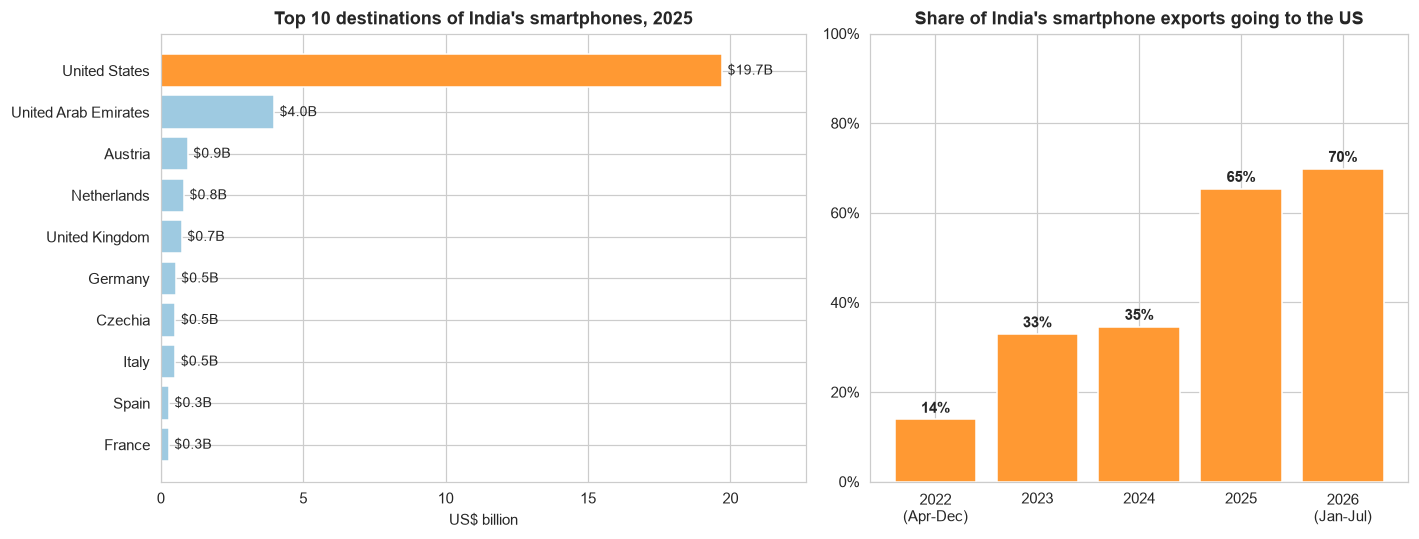

In [17]:
top10 = india[india["year"] == 2025].groupby("country")["value_usd"].sum().sort_values(ascending=False).head(10) / 1e9

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.2, 1]})

bar_colors = [colors["India"] if c == "United States" else "#9ECAE1" for c in top10.index]
axes[0].barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1])
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v + 0.2, i, f"${v:.1f}B", va="center", fontsize=9)
axes[0].set_title("Top 10 destinations of India's smartphones, 2025", fontweight="bold")
axes[0].set_xlabel("US$ billion")
axes[0].set_xlim(0, top10.max() * 1.15)

axes[1].bar(range(len(india_summary)), india_summary["US share %"], color=colors["India"])
for i, v in enumerate(india_summary["US share %"]):
    axes[1].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontweight="bold")
axes[1].set_xticks(range(len(india_summary)))
axes[1].set_xticklabels(["2022\n(Apr-Dec)", "2023", "2024", "2025", "2026\n(Jan-Jul)"])
axes[1].set_ylim(0, 100)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Share of India's smartphone exports going to the US", fontweight="bold")

plt.tight_layout()
plt.savefig("../images/05_india_destinations.png", bbox_inches="tight")
plt.show()

**What I found:**
- India's smartphone exports grew from **$14.3B in 2023 to $30.1B in 2025**.
- The US took **65% of it in 2025** and **70% so far in 2026**, up from 14% in 2022.
- UAE is a distant second (it's a big re-export hub for the Middle East and Africa). Europe is spread across many
  small markets.
- **This is also a risk.** Seven out of every ten phones India exports now depend on one country's trade policy.
  When the US put 50% tariffs on many Indian goods in August 2025, smartphones were left out; if that ever
  changes, this whole industry is exposed.

## Q6. Do India's numbers and America's numbers match?

The same shipment is recorded twice: once by India when it leaves, once by the US when it arrives. In theory
they should be equal. Let's check.

In [18]:
mirror = pd.DataFrame({
    "US says (imports from India)": us[us["country"] == "India"].groupby("date")["value_usd"].sum() / 1e9,
    "India says (exports to US)": india[india["country"] == "United States"].groupby("date")["value_usd"].sum() / 1e9,
}).dropna()

mirror_yearly = mirror.groupby(mirror.index.year).sum()
mirror_yearly["gap %"] = (mirror_yearly.iloc[:, 0] / mirror_yearly.iloc[:, 1] - 1) * 100
mirror_yearly.round(2)

,US says (imports from India),India says (exports to US),gap %
date,,,
2022,1.05,1.00,5.73
2023,5.01,4.70,6.64
2024,7.04,7.07,-0.45
2025,22.15,19.70,12.41
2026,16.45,14.90,10.38


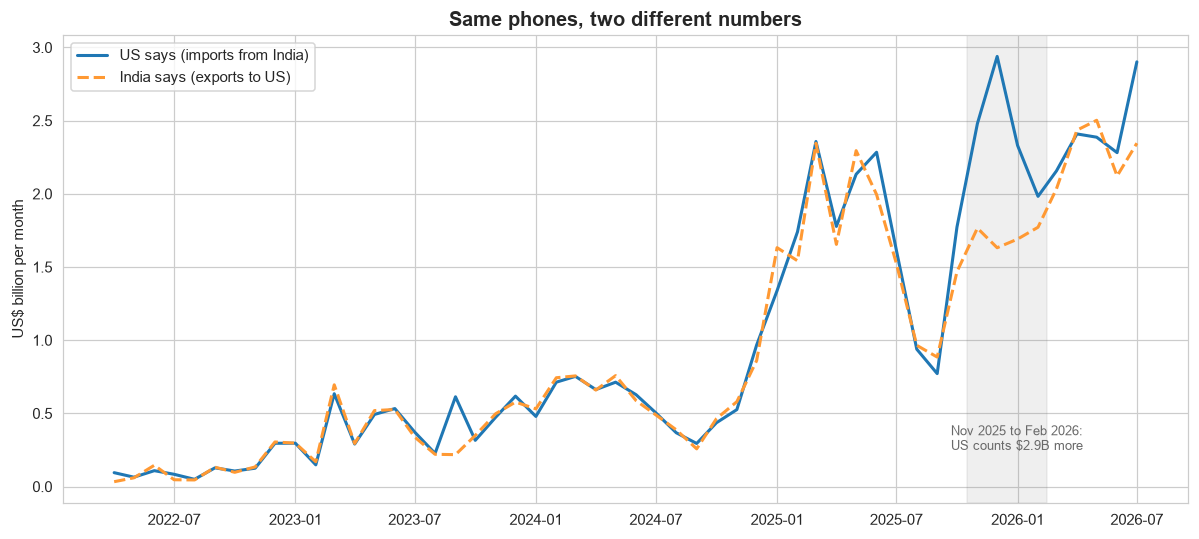

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mirror.index, mirror.iloc[:, 0], label="US says (imports from India)", color="#1F77B4", linewidth=2)
ax.plot(mirror.index, mirror.iloc[:, 1], label="India says (exports to US)", color=colors["India"], linewidth=2, linestyle="--")
ax.axvspan(pd.Timestamp("2025-10-16"), pd.Timestamp("2026-02-15"), color="gray", alpha=0.12)
ax.text(pd.Timestamp("2025-12-31"), 0.25, "Nov 2025 to Feb 2026:\nUS counts $2.9B more", ha="center", fontsize=8.5, color="dimgray")
ax.set_title("Same phones, two different numbers", fontsize=13, fontweight="bold")
ax.set_ylabel("US$ billion per month")
ax.legend()
plt.tight_layout()
plt.savefig("../images/06_mirror_check.png", bbox_inches="tight")
plt.show()

Where exactly is the gap?

In [20]:
mirror["gap"] = mirror.iloc[:, 0] - mirror.iloc[:, 1]
before = mirror.loc[:"2025-10"]
print("Apr 2022 to Oct 2025: US number is {:.1f}% higher".format((before.iloc[:, 0].sum() / before.iloc[:, 1].sum() - 1) * 100))
print("Nov 2025 to Feb 2026: gap = ${:.2f}B".format(mirror.loc["2025-11":"2026-02", "gap"].sum()))
mirror.loc["2025-09":"2026-03"].round(2)

Apr 2022 to Oct 2025: US number is 2.6% higher
Nov 2025 to Feb 2026: gap = $2.87B


,US says (imports from India),India says (exports to US),gap
date,,,
2025-09-01,0.77,0.88,-0.11
2025-10-01,1.77,1.47,0.31
2025-11-01,2.48,1.77,0.71
2025-12-01,2.94,1.63,1.31
2026-01-01,2.33,1.69,0.64
2026-02-01,1.98,1.77,0.21
2026-03-01,2.16,2.03,0.12


**What I found:**
- From 2022 to October 2025 the two lines are almost on top of each other. The US number is only about **3% higher**,
  which is roughly what you expect from **CIF vs FOB** (the US value includes shipping and insurance, India's doesn't).
- Then from **November 2025 to February 2026** the US counted **$2.9B more** than India reported, more than the gap for all
  of 2025 put together. I couldn't find the reason in this data. Possible reasons I read about for "mirror statistics":
  - The US records the country where a phone was **made**, while India records the country it was **sent to**. Phones
    made in India but shipped through another country count as "from India" for the US, but not as "to the US" for India.
  - **Timing:** holiday-season shipments leaving India at the end of one month may be counted by the US the next month.
  - One of the two countries may **revise** these months later.

Because of this, in Q1 to Q4 I only used US data, and in Q5 only India's data, instead of mixing the two.

## Summary

| # | Finding |
|---|---|
| 1 | India's smartphone sales to the US grew **~35x** (Jan to Jul 2022 vs 2026) while the total US market shrank |
| 2 | India overtook China for the first time in **April 2025**, the month of the new US tariffs |
| 3 | India's share still dips every **September**; China still leads iPhone launch season, but the gap is closing |
| 4 | India ships the **most expensive** phones ($533 average vs China $357, Vietnam $242), which fits with iPhones |
| 5 | **70%** of India's smartphone exports now go to the US, a big dependence on one market |
| 6 | US and Indian numbers for the same phones matched within ~3% until Oct 2025, then a **$2.9B gap** opened (Nov 2025 to Feb 2026) |

**Limitations**
- Trade data doesn't show brand or model, so "these are iPhones" is based on the price and on news reports, not proven
  by this data.
- Monthly Comtrade data can be revised later; the latest months are the most likely to change.
- 2022 quantities (US) are estimated, so no price analysis for 2022.
- This is correlation. The tariffs came at the same time as India's jump, but Apple's supply shift to India started before.